# Tomography Lite Tutorial
*Cedric Lim, March 3, 2026*

This tutorial shows the usage of `TomographyLite` for conventional and machine-learning enabled reconstruction methods. These methods abstract arguments in the instantiation of the top-level `Tomography` class, i.e instantiation of object and dataset models. 

See `tomography_02_full.ipynb` to see the full reconstruction workflow.

In [ ]:
%load_ext autoreload
%autoreload 2

%load_ext tensorboard
%tensorboard --logdir ../../../outputs/tomography/tutorial_01_notebooks/tomo_inr_lite


In [2]:
from quantem.tomography.tomography_lite import TomographyLiteConv, TomographyLiteINR
import numpy as np
from quantem.core.visualization import show_2d

from quantem.core.utils.tomography_utils import fourier_binning

device = "cuda:1" # Set device

/home/cedlim/quantem/quantem/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Launch Tensorboard

In [ ]:
from tensorboard import notebook
notebook.list() # View open TensorBoard instances
notebook.display(port=6006, height=1000)

# Loading Dataset

The simulated phantom dataset loaded here is a sparse tilt seriesw ith a tilt step of 5 degrees from $\pm70^\circ$ containing a $1^\circ$ tilt-axis error in the tilt series 

In [4]:
# Load Ground Truth Phantom
gt_phantom = np.load('../../../data/phantom.npy').transpose(2, 0, 1)
# Load Phantom Dataset
tilt_series = np.load('../../../data/tilt_series_1_deg_tilt_axis.npy')
tilt_angles = np.load('../../../data/tilt_angles_1_deg_tilt_axis.npy')

# Fourier crop
tilt_series = np.array([fourier_binning(img, (100, 100)) for img in tilt_series]) # Cropped down to 100x100 for speed


(<Figure size 1200x400 with 3 Axes>,
 array([<Axes: title={'center': 'Tilt -70.0'}>,
        <Axes: title={'center': 'Tilt -35.0'}>,
        <Axes: title={'center': 'Tilt 55.0'}>], dtype=object))

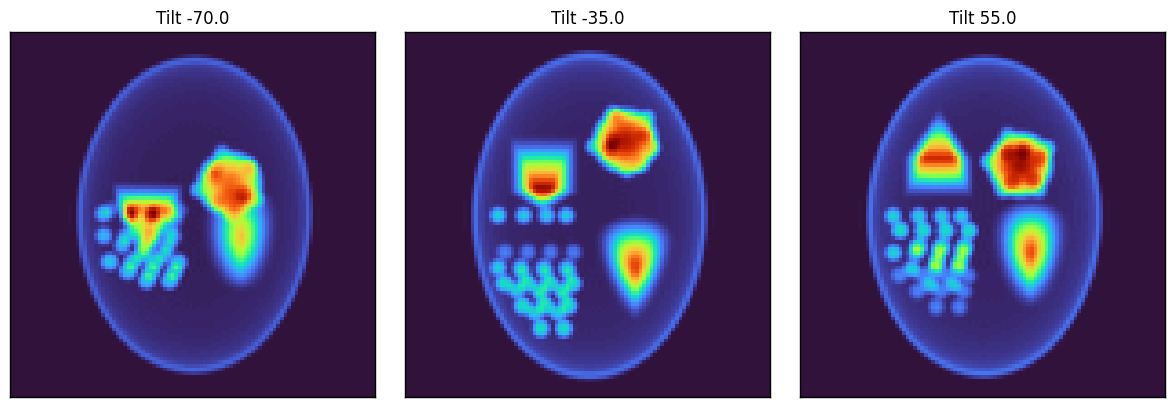

In [5]:
show_2d(
    [tilt_series[0], tilt_series[7], tilt_series[25]],
    title = [f'Tilt {tilt_angles[0]}', f'Tilt {tilt_angles[7]}', f'Tilt {tilt_angles[25]}'],
    cmap = 'turbo',
    vmin = 0,
    vmax = None,
)

# Conventional Tomography Reconstructions

The default conventional algorithm is simultaneous iterative reconstruction technique (**SIRT**).

In [6]:
tomography = TomographyLiteConv.from_dataset(
    tilt_series = tilt_series,
    tilt_angles = tilt_angles,
    device = device,
)

In [7]:
tomography.reconstruct(
    num_iter = 10,
    mode = "sirt",
    inline_alignment = True,
    smoothing_sigma = 0.5,
)

sirt Reconstruction:   0%|          | 0/10 [00:00<?, ?it/s]

proj_forward.shape torch.Size([100, 29, 100])
self.dset.tilt_stack.shape torch.Size([29, 100, 100])


sirt Reconstruction | Loss: 0.0262: 100%|██████████| 10/10 [00:00<00:00, 16.15it/s]


(<Figure size 1200x400 with 3 Axes>,
 array([<Axes: title={'center': 'Conventional Reconstruction Summed X'}>,
        <Axes: title={'center': 'Conventional Reconstruction Summed Y'}>,
        <Axes: title={'center': 'Conventional Reconstruction Summed Z'}>],
       dtype=object))

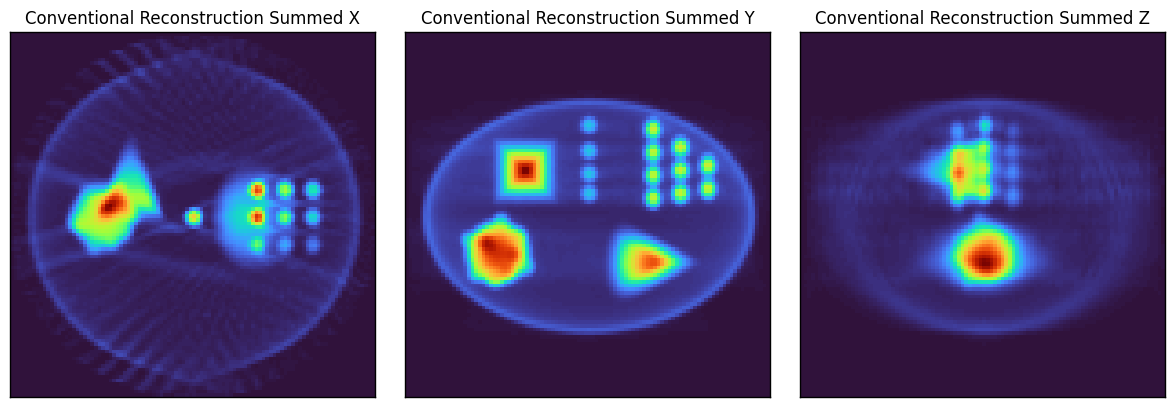

In [8]:
obj_conv = tomography.obj_model.obj.detach().cpu().numpy()
show_2d(
    [obj_conv.sum(axis = 0), obj_conv.sum(axis = 1), obj_conv.sum(axis = 2)],
    title = ['Conventional Reconstruction Summed X', 'Conventional Reconstruction Summed Y', 'Conventional Reconstruction Summed Z'],
    cmap = 'turbo',
    vmin = 0,
    vmax = None,
)

The reconstruction here shows artifacts from the small missing wedges due to the large tilt step. Moreover, in the summed Z direction there are some misalignment artifacts due to the tilt-axis error.

# INR-Based Tomography Reconstruction

In [9]:
tomography_inr = TomographyLiteINR.from_dataset(
    tilt_series = tilt_series,
    tilt_angles = tilt_angles,
    device = device,
    log_dir = '../../../outputs/tomography/tutorial_01_notebooks/tomo_inr_lite',
    log_images_every = 2,
)


Model built, compiled successfully
Setting up DDP for obj_model


In [10]:
obj_constraints = {
    "positivity": True,
    "tv_vol": 1e-4,
    "sparsity": 1e-6,
}

dset_constraints = {
    "tv_zs": 1e-6,
    "tv_shifts": 1e-6,
}   

tomography_inr.reconstruct(
    num_iter = 30,
    # reset = True,
    obj_lr = 1e-4,
    pose_lr = 1e-2,
    batch_size = 1024,
    num_workers = 32,
    learn_pose = True,
    scheduler_type = "cosine_annealing",
    obj_constraints = obj_constraints,
    dset_constraints = dset_constraints,
)

Dataloader setup complete:
  Total train samples: 290000
  Local batch size: 1024
  Global batch size: 1024
  Train batches per GPU per epoch: 283


Reconstruction | Loss: 0.0005, Consistency Loss: 0.0001, Soft Constraint Loss: 0.0005 | Logger Updated: 100%|██████████| 30/30 [02:10<00:00,  4.34s/it]


(<Figure size 1200x400 with 3 Axes>,
 array([<Axes: title={'center': 'INR-Based Reconstruction Summed X'}>,
        <Axes: title={'center': 'INR-Based Reconstruction Summed Y'}>,
        <Axes: title={'center': 'INR-Based Reconstruction Summed Z'}>],
       dtype=object))

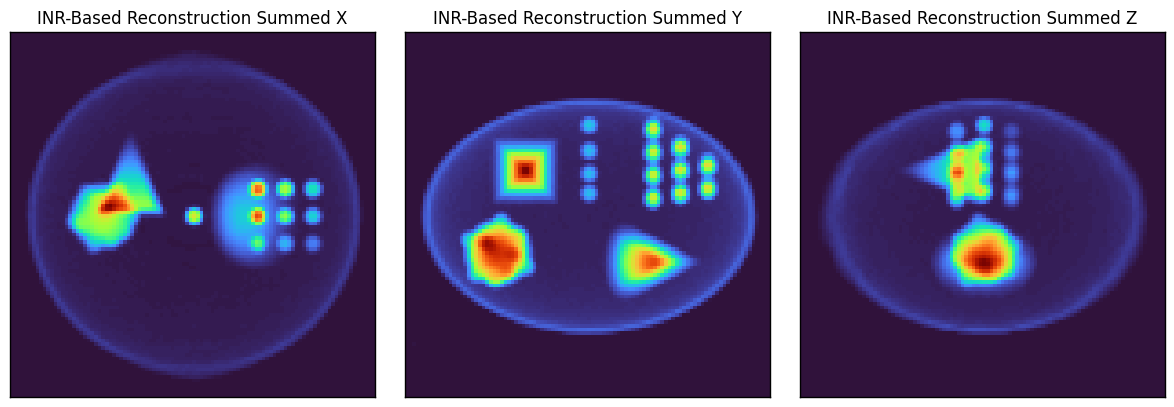

In [14]:
obj_inr = tomography_inr.obj_model.obj_view
show_2d(
    [obj_inr[0].sum(axis = 0), obj_inr[0].sum(axis = 1), obj_inr[0].sum(axis = 2)],
    cmap = 'turbo',
    title = ['INR-Based Reconstruction Summed X', 'INR-Based Reconstruction Summed Y', 'INR-Based Reconstruction Summed Z'],
    vmin = 0,
    vmax = None,
)

# Compare Both Reconstruction Methods

(<Figure size 1200x1200 with 9 Axes>,
 array([[<Axes: title={'center': 'Conventional Reconstruction Summed X'}>,
         <Axes: title={'center': 'Conventional Reconstruction Summed Y'}>,
         <Axes: title={'center': 'Conventional Reconstruction Summed Z'}>],
        [<Axes: title={'center': 'INR-Based Reconstruction Summed X'}>,
         <Axes: title={'center': 'INR-Based Reconstruction Summed Y'}>,
         <Axes: title={'center': 'INR-Based Reconstruction Summed Z'}>],
        [<Axes: title={'center': 'Ground Truth Phantom Summed X'}>,
         <Axes: title={'center': 'Ground Truth Phantom Summed Y'}>,
         <Axes: title={'center': 'Ground Truth Phantom Summed Z'}>]],
       dtype=object))

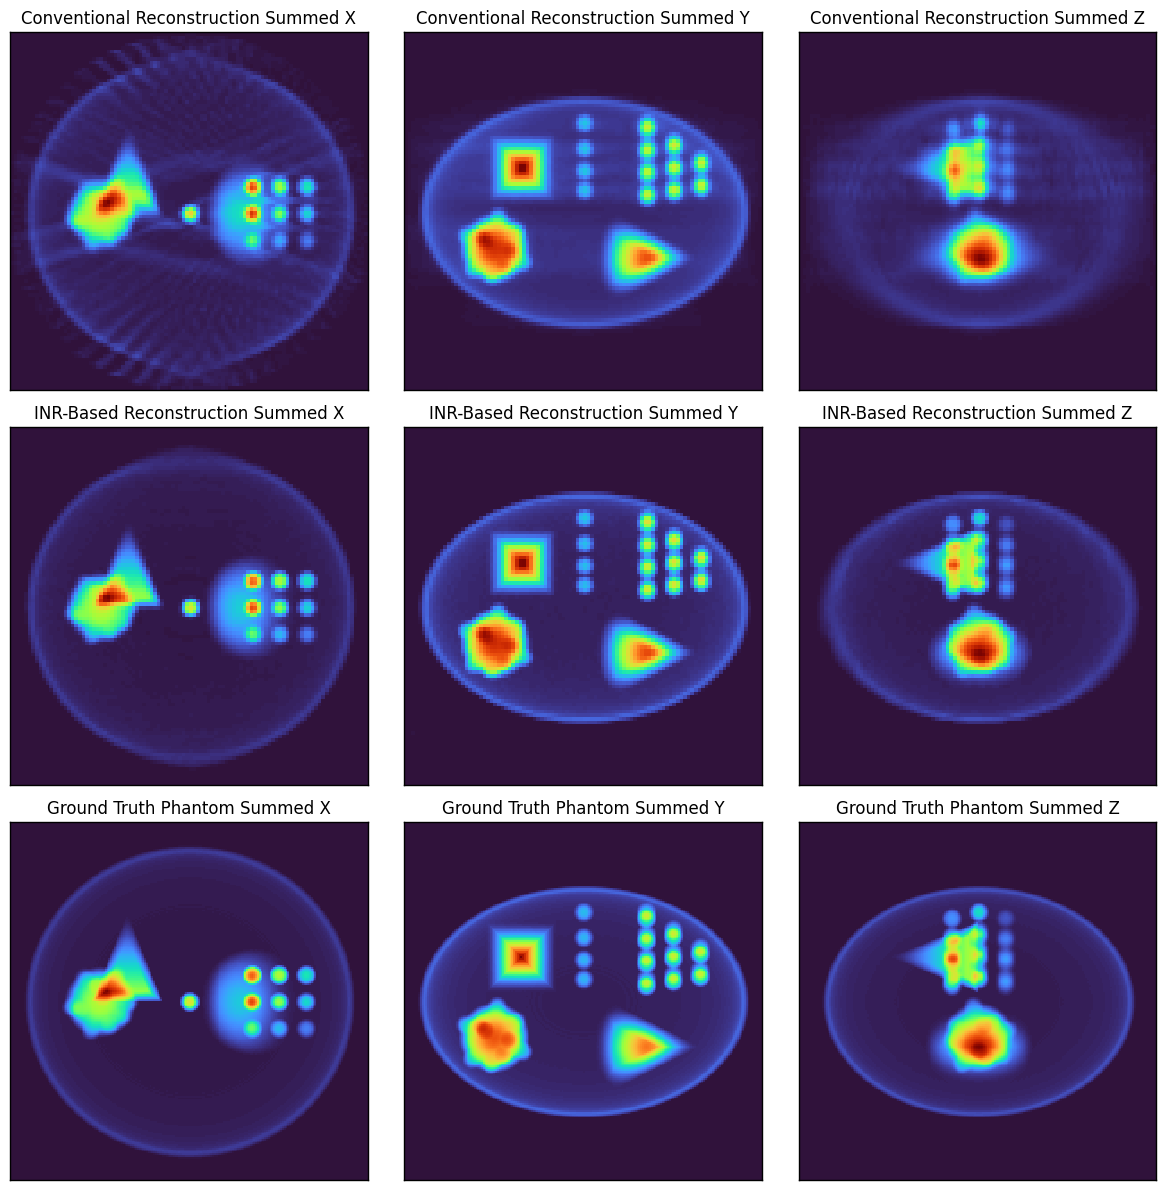

In [16]:
show_2d(
    [
        [obj_conv.sum(axis = 0), obj_conv.sum(axis = 1), obj_conv.sum(axis = 2)],
        [obj_inr[0].sum(axis = 0), obj_inr[0].sum(axis = 1), obj_inr[0].sum(axis = 2)],
        [gt_phantom.sum(axis = 0), gt_phantom.sum(axis = 1), gt_phantom.sum(axis = 2)],
    ],
    title = [
        ['Conventional Reconstruction Summed X', 'Conventional Reconstruction Summed Y', 'Conventional Reconstruction Summed Z'],
        ['INR-Based Reconstruction Summed X', 'INR-Based Reconstruction Summed Y', 'INR-Based Reconstruction Summed Z'],
        ['Ground Truth Phantom Summed X', 'Ground Truth Phantom Summed Y', 'Ground Truth Phantom Summed Z']
    ],
    cmap = 'turbo',
    vmin = 0,
)

# Saving the Object or Volume

In [19]:
tomography_inr.save("../../../outputs/tomography/tutorial_01_notebooks/tomo_inr_lite/tomo_lite.zip", mode = "o")

falling back in serialize for _device of type <class 'torch.device'>


In [ ]:
# The device is important as it will automatically default to the CPU if not specified causing CUDA errors.
tomo = TomographyLiteINR.from_file("../../../outputs/tomography/tutorial_01_notebooks/tomo_inr_lite/tomo_lite.zip", device = device)

Dataloader setup complete:
  Total train samples: 290000
  Local batch size: 1024
  Global batch size: 1024
  Train batches per GPU per epoch: 283


You can continue training from the loaded object as well.

In [24]:
tomo.reconstruct(num_iter = 5)

Reconstruction | Loss: 0.0006, Consistency Loss: 0.0001, Soft Constraint Loss: 0.0005 | Logger Updated: 100%|██████████| 5/5 [00:25<00:00,  5.16s/it]


## Saving Volume

In [25]:
tomography_inr.save_volume("../../../outputs/tomography/tutorial_01_notebooks/tomo_inr_lite/tomo_lite_volume.npz")

Saving volume to ../../../outputs/tomography/tutorial_01_notebooks/tomo_inr_lite/tomo_lite_volume.npz


(<Figure size 1200x400 with 3 Axes>,
 array([<Axes: title={'center': 'Summed X'}>,
        <Axes: title={'center': 'Summed Y'}>,
        <Axes: title={'center': 'Summed Z'}>], dtype=object))

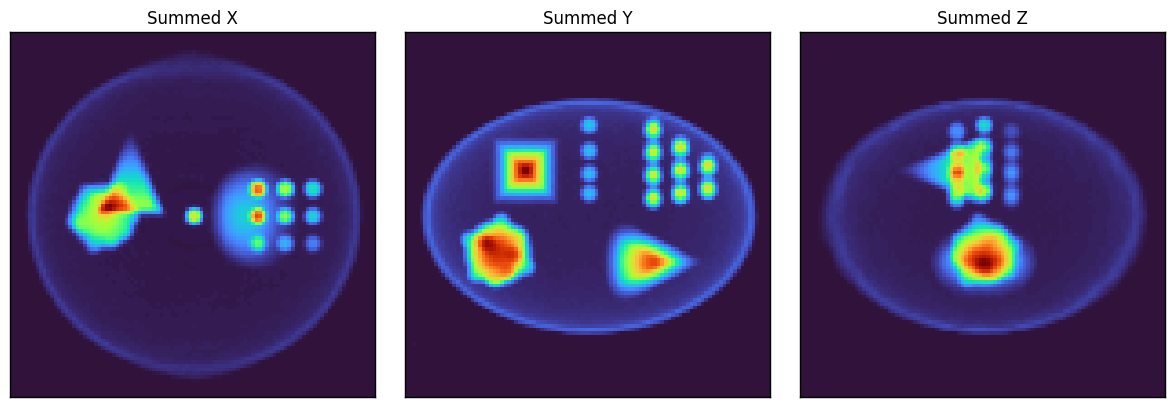

In [26]:
saved_vol = np.load("../../../outputs/tomography/tutorial_01_notebooks/tomo_inr_lite/tomo_lite_volume.npz")
show_2d(
    [
        saved_vol["volume"][0].sum(axis = 0),
        saved_vol["volume"][0].sum(axis = 1),
        saved_vol["volume"][0].sum(axis = 2),
    ],
    title = [
        "Summed X",
        "Summed Y",
        "Summed Z",
    ],
    cmap = "turbo",
    vmin = 0,
    vmax = None,
)